In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# WTA Data Analysis

####  by Nazgul Altynbekova 



In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from pylab import rcParams

%matplotlib inline

In [4]:
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)


In [5]:
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 40)

In [6]:
rcParams['figure.figsize'] = 15, 10
rcParams['font.size'] = 20

# 1. Wrangling, reshaping, EDA

### Collecting data

In [9]:
wta14 = pd.read_excel("./datasets/2014.xlsx")
wta15 = pd.read_excel("./datasets/2015.xlsx")
wta16 = pd.read_excel("./datasets/2016.xlsx")
wta17 = pd.read_excel("./datasets/2017.xlsx")
wta18 = pd.read_excel("./datasets/2018.xlsx")
wta19 = pd.read_excel("./datasets/2019.xlsx")
wta20 = pd.read_excel("./datasets/2020.xlsx")
wta21 = pd.read_excel("./datasets/2021.xlsx")
wta22 = pd.read_excel("./datasets/2022.xlsx")
wta23 = pd.read_excel("./datasets/2023.xlsx")

In [10]:
wta = pd.concat([wta14, wta15, wta16, wta17, wta18, wta19, wta20, wta21, wta22, wta23], 
                ignore_index = True, sort = False) 
wta.head()

,WTA,Location,Tournament,Date,Tier,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,WPts,LPts,W1,L1,W2,L2,W3,L3,Wsets,Lsets,Comment,B365W,B365L,EXW,EXL,LBW,LBL,PSW,PSL,SJW,SJL,MaxW,MaxL,AvgW,AvgL
0,1,Auckland,ASB Classic,2013-12-30,International,Outdoor,Hard,1st Round,3,Muguruza G.,Mchale C.,63.0,66.0,933.0,882.0,6.0,4.0,6.0,3.0,NaN,NaN,2.0,0.0,Completed,2.20,1.61,2.45,1.52,2.10,1.67,2.43,1.62,2.25,1.57,2.58,1.67,2.34,1.57
1,1,Auckland,ASB Classic,2013-12-30,International,Outdoor,Hard,1st Round,3,Meusburger Y.,Barthel M.,49.0,34.0,1138.0,1545.0,6.0,4.0,6.0,3.0,NaN,NaN,2.0,0.0,Completed,2.50,1.50,2.40,1.55,2.50,1.50,2.39,1.64,2.50,1.50,2.50,1.67,2.38,1.56
2,1,Auckland,ASB Classic,2013-12-30,International,Outdoor,Hard,1st Round,3,Pliskova Ka.,Ormaechea P.,71.0,62.0,839.0,954.0,7.0,6.0,6.0,1.0,NaN,NaN,2.0,0.0,Completed,1.57,2.25,1.62,2.25,1.57,2.25,1.61,2.46,1.62,2.20,1.67,2.46,1.60,2.30
3,1,Auckland,ASB Classic,2013-12-30,International,Outdoor,Hard,1st Round,3,Hampton J.,Paszek T.,28.0,179.0,1781.0,355.0,1.0,6.0,6.0,0.0,6.0,3.0,2.0,1.0,Completed,1.20,4.33,1.25,3.75,1.25,3.75,1.24,4.44,1.22,3.75,1.29,4.60,1.26,3.82
4,1,Auckland,ASB Classic,2013-12-30,International,Outdoor,Hard,1st Round,3,Larsson J.,Dominguez Lino L.,84.0,69.0,753.0,842.0,7.0,5.0,6.0,0.0,NaN,NaN,2.0,0.0,Completed,1.61,2.20,1.55,2.40,1.67,2.10,1.68,2.31,1.62,2.20,1.68,2.40,1.60,2.28


### Checking the dataset

In [12]:
# to check if files has been read completely
print(wta14.shape)
print(wta15.shape)
print(wta16.shape)
print(wta17.shape)
print(wta18.shape)
print(wta19.shape)
print(wta20.shape)
print(wta21.shape)
print(wta22.shape)
print(wta23.shape)

(2476, 38)
(2521, 36)
(2522, 36)
(2500, 36)
(2469, 36)
(2472, 32)
(1055, 32)
(2447, 32)
(2369, 32)
(2491, 32)


In [13]:
#to check if concatenated dataset haven't lost anything in the process
filescount =  sum(df.count().sum() for df in [wta14, wta15, wta16, wta17, wta18, wta19, wta20, wta21, wta22, wta23])
allcount = wta.count().sum() 

if filescount == allcount:
    print('Combined dataset is complete')
else:
    print('Combined dataset is NOT complete')

Combined dataset is complete


In [14]:
#to arrange dataset in ascending order by Date with new indexes
wta = wta.sort_values(by = ['Date'], ignore_index = True)
wta

,WTA,Location,Tournament,Date,Tier,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,WPts,LPts,W1,L1,W2,L2,W3,L3,Wsets,Lsets,Comment,B365W,B365L,EXW,EXL,LBW,LBL,PSW,PSL,SJW,SJL,MaxW,MaxL,AvgW,AvgL
0,3,Shenzhen,Shenzhen Open,2013-12-29,International,Outdoor,Hard,1st Round,3,Soler Espinosa S.,Tsurenko L.,82.0,68.0,773.0,872.0,6.0,4.0,7.0,6.0,NaN,NaN,2.0,0.0,Completed,2.50,1.50,2.40,1.55,2.38,1.53,2.43,1.63,NaN,NaN,2.50,1.65,2.35,1.57
1,2,Brisbane,Brisbane International,2013-12-29,Premier,Outdoor,Hard,1st Round,3,Svitolina E.,Lepchenko V.,45.0,54.0,1160.0,1087.0,6.0,3.0,6.0,3.0,NaN,NaN,2.0,0.0,Completed,1.83,1.83,2.00,1.80,2.10,1.67,2.06,1.84,2.10,1.67,2.10,1.89,2.00,1.77
2,2,Brisbane,Brisbane International,2013-12-29,Premier,Outdoor,Hard,1st Round,3,Lisicki S.,Rybarikova M.,15.0,37.0,2920.0,1450.0,6.0,3.0,6.0,4.0,NaN,NaN,2.0,0.0,Completed,1.28,3.50,1.35,3.10,1.36,3.00,1.34,3.49,1.36,2.88,1.40,3.55,1.33,3.20
3,2,Brisbane,Brisbane International,2013-12-29,Premier,Outdoor,Hard,1st Round,3,Voegele S.,Keys M.,50.0,38.0,1130.0,1380.0,6.0,4.0,6.0,3.0,NaN,NaN,2.0,0.0,Completed,3.25,1.33,2.50,1.50,2.50,1.50,2.83,1.48,2.50,1.50,3.25,1.50,2.64,1.46
4,2,Brisbane,Brisbane International,2013-12-29,Premier,Outdoor,Hard,1st Round,3,Petkovic A.,Mattek-Sands B.,43.0,48.0,1217.0,1144.0,6.0,4.0,7.0,5.0,NaN,NaN,2.0,0.0,Completed,1.36,3.00,1.45,2.70,1.50,2.50,1.46,2.90,1.50,2.50,1.50,3.00,1.44,2.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23317,57,Cancun,WTA Finals,2023-11-03,Tour Championships,Outdoor,Hard,Round Robin,3,Gauff C.,Vondrousova M.,3.0,6.0,5955.0,3839.0,5.0,7.0,7.0,6.0,6.0,3.0,2.0,1.0,Completed,1.36,3.20,NaN,NaN,NaN,NaN,1.36,3.46,NaN,NaN,1.43,3.46,1.35,3.20
23318,57,Cancun,WTA Finals,2023-11-04,Tour Championships,Outdoor,Hard,Round Robin,3,Swiatek I.,Jabeur O.,2.0,7.0,7795.0,3695.0,6.0,1.0,6.0,2.0,NaN,NaN,2.0,0.0,Completed,1.14,5.50,NaN,NaN,NaN,NaN,1.15,6.53,NaN,NaN,1.15,6.85,1.13,5.89
23319,57,Cancun,WTA Finals,2023-11-04,Tour Championships,Outdoor,Hard,Semifinals,3,Pegula J.,Gauff C.,5.0,3.0,4895.0,5955.0,6.0,2.0,6.0,1.0,NaN,NaN,2.0,0.0,Completed,1.73,2.00,NaN,NaN,NaN,NaN,1.78,2.16,NaN,NaN,1.92,2.16,1.76,2.06
23320,57,Cancun,WTA Finals,2023-11-05,Tour Championships,Outdoor,Hard,The Final,3,Swiatek I.,Sabalenka A.,2.0,1.0,7795.0,8425.0,6.0,3.0,6.0,2.0,NaN,NaN,2.0,0.0,Completed,1.33,3.25,NaN,NaN,NaN,NaN,1.36,3.44,NaN,NaN,1.40,3.65,1.35,3.20


### Other sanity checking

In [16]:
#checking if there are whole columns or rows of missing values 
pd.isnull(wta)
wta.dropna(how = 'all')
wta.dropna(axis = 1, how = 'all')


,WTA,Location,Tournament,Date,Tier,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,WPts,LPts,W1,L1,W2,L2,W3,L3,Wsets,Lsets,Comment,B365W,B365L,EXW,EXL,LBW,LBL,PSW,PSL,SJW,SJL,MaxW,MaxL,AvgW,AvgL
0,3,Shenzhen,Shenzhen Open,2013-12-29,International,Outdoor,Hard,1st Round,3,Soler Espinosa S.,Tsurenko L.,82.0,68.0,773.0,872.0,6.0,4.0,7.0,6.0,NaN,NaN,2.0,0.0,Completed,2.50,1.50,2.40,1.55,2.38,1.53,2.43,1.63,NaN,NaN,2.50,1.65,2.35,1.57
1,2,Brisbane,Brisbane International,2013-12-29,Premier,Outdoor,Hard,1st Round,3,Svitolina E.,Lepchenko V.,45.0,54.0,1160.0,1087.0,6.0,3.0,6.0,3.0,NaN,NaN,2.0,0.0,Completed,1.83,1.83,2.00,1.80,2.10,1.67,2.06,1.84,2.10,1.67,2.10,1.89,2.00,1.77
2,2,Brisbane,Brisbane International,2013-12-29,Premier,Outdoor,Hard,1st Round,3,Lisicki S.,Rybarikova M.,15.0,37.0,2920.0,1450.0,6.0,3.0,6.0,4.0,NaN,NaN,2.0,0.0,Completed,1.28,3.50,1.35,3.10,1.36,3.00,1.34,3.49,1.36,2.88,1.40,3.55,1.33,3.20
3,2,Brisbane,Brisbane International,2013-12-29,Premier,Outdoor,Hard,1st Round,3,Voegele S.,Keys M.,50.0,38.0,1130.0,1380.0,6.0,4.0,6.0,3.0,NaN,NaN,2.0,0.0,Completed,3.25,1.33,2.50,1.50,2.50,1.50,2.83,1.48,2.50,1.50,3.25,1.50,2.64,1.46
4,2,Brisbane,Brisbane International,2013-12-29,Premier,Outdoor,Hard,1st Round,3,Petkovic A.,Mattek-Sands B.,43.0,48.0,1217.0,1144.0,6.0,4.0,7.0,5.0,NaN,NaN,2.0,0.0,Completed,1.36,3.00,1.45,2.70,1.50,2.50,1.46,2.90,1.50,2.50,1.50,3.00,1.44,2.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23317,57,Cancun,WTA Finals,2023-11-03,Tour Championships,Outdoor,Hard,Round Robin,3,Gauff C.,Vondrousova M.,3.0,6.0,5955.0,3839.0,5.0,7.0,7.0,6.0,6.0,3.0,2.0,1.0,Completed,1.36,3.20,NaN,NaN,NaN,NaN,1.36,3.46,NaN,NaN,1.43,3.46,1.35,3.20
23318,57,Cancun,WTA Finals,2023-11-04,Tour Championships,Outdoor,Hard,Round Robin,3,Swiatek I.,Jabeur O.,2.0,7.0,7795.0,3695.0,6.0,1.0,6.0,2.0,NaN,NaN,2.0,0.0,Completed,1.14,5.50,NaN,NaN,NaN,NaN,1.15,6.53,NaN,NaN,1.15,6.85,1.13,5.89
23319,57,Cancun,WTA Finals,2023-11-04,Tour Championships,Outdoor,Hard,Semifinals,3,Pegula J.,Gauff C.,5.0,3.0,4895.0,5955.0,6.0,2.0,6.0,1.0,NaN,NaN,2.0,0.0,Completed,1.73,2.00,NaN,NaN,NaN,NaN,1.78,2.16,NaN,NaN,1.92,2.16,1.76,2.06
23320,57,Cancun,WTA Finals,2023-11-05,Tour Championships,Outdoor,Hard,The Final,3,Swiatek I.,Sabalenka A.,2.0,1.0,7795.0,8425.0,6.0,3.0,6.0,2.0,NaN,NaN,2.0,0.0,Completed,1.33,3.25,NaN,NaN,NaN,NaN,1.36,3.44,NaN,NaN,1.40,3.65,1.35,3.20


<Axes: title={'center': 'Missing Values in Each Column'}>

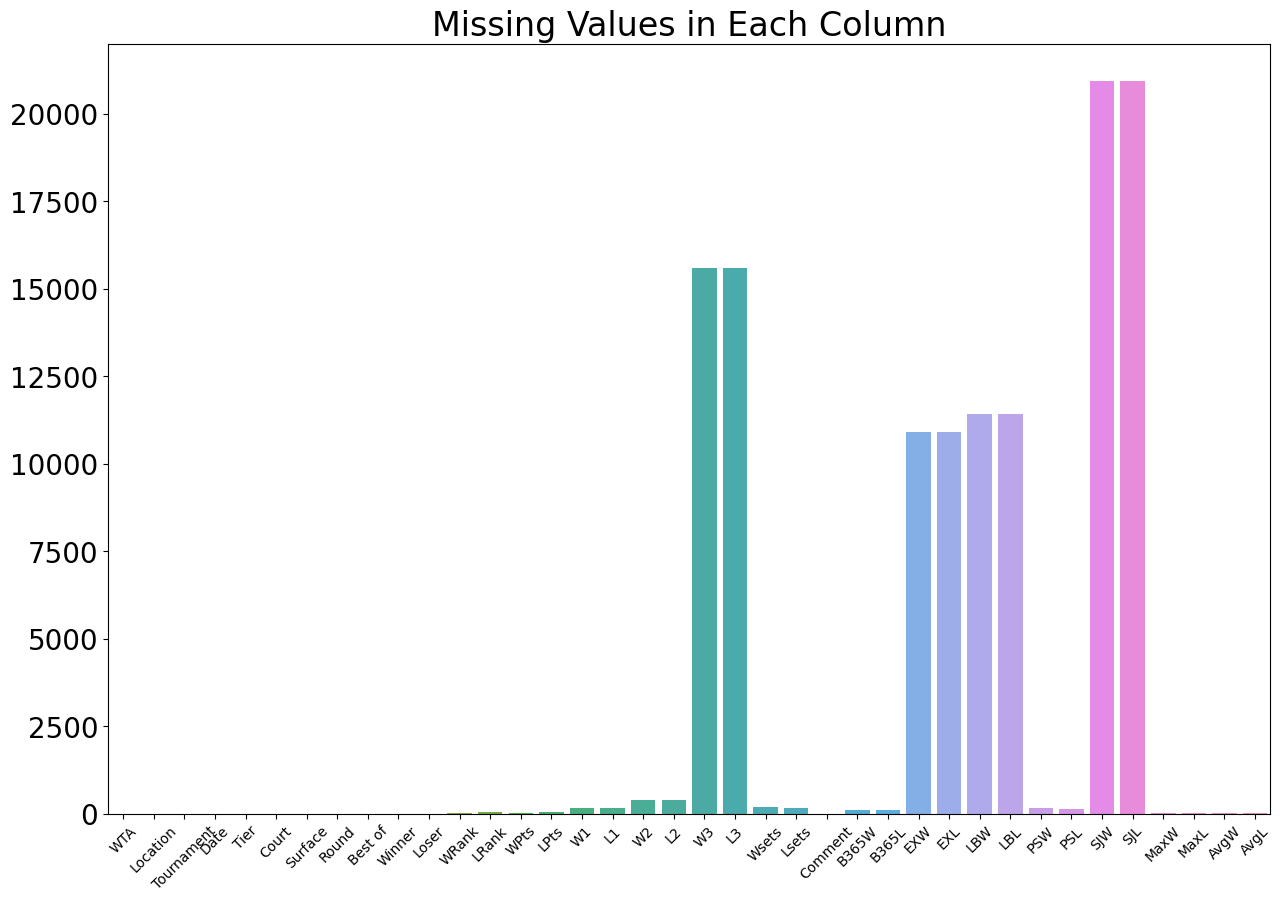

In [17]:
#plotting to see how distribution of missing values looks like in each column
missing_values = wta.isnull().sum()
mv = sns.barplot(x = missing_values.index, y = missing_values.values)
plt.xticks(rotation = 45, fontsize = 10)
plt.title('Missing Values in Each Column')
mv

In [18]:
#replacing all missing values with 0
wta.fillna(0, inplace = True)

In [19]:
#checking how distribution of all features looks like to see if there're potential issues
#pd.plotting.scatter_matrix(wta, figsize = (20, 15), diagonal = 'hist')
#plt.xticks(rotation = 45, fontsize = 10)
#plt.yticks(rotation = 0, fontsize = 10)


In [20]:
#checking for duplicates
wta.drop_duplicates()

,WTA,Location,Tournament,Date,Tier,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,WPts,LPts,W1,L1,W2,L2,W3,L3,Wsets,Lsets,Comment,B365W,B365L,EXW,EXL,LBW,LBL,PSW,PSL,SJW,SJL,MaxW,MaxL,AvgW,AvgL
0,3,Shenzhen,Shenzhen Open,2013-12-29,International,Outdoor,Hard,1st Round,3,Soler Espinosa S.,Tsurenko L.,82.0,68.0,773.0,872.0,6.0,4.0,7.0,6.0,0.0,0.0,2.0,0.0,Completed,2.50,1.50,2.40,1.55,2.38,1.53,2.43,1.63,0.00,0.00,2.50,1.65,2.35,1.57
1,2,Brisbane,Brisbane International,2013-12-29,Premier,Outdoor,Hard,1st Round,3,Svitolina E.,Lepchenko V.,45.0,54.0,1160.0,1087.0,6.0,3.0,6.0,3.0,0.0,0.0,2.0,0.0,Completed,1.83,1.83,2.00,1.80,2.10,1.67,2.06,1.84,2.10,1.67,2.10,1.89,2.00,1.77
2,2,Brisbane,Brisbane International,2013-12-29,Premier,Outdoor,Hard,1st Round,3,Lisicki S.,Rybarikova M.,15.0,37.0,2920.0,1450.0,6.0,3.0,6.0,4.0,0.0,0.0,2.0,0.0,Completed,1.28,3.50,1.35,3.10,1.36,3.00,1.34,3.49,1.36,2.88,1.40,3.55,1.33,3.20
3,2,Brisbane,Brisbane International,2013-12-29,Premier,Outdoor,Hard,1st Round,3,Voegele S.,Keys M.,50.0,38.0,1130.0,1380.0,6.0,4.0,6.0,3.0,0.0,0.0,2.0,0.0,Completed,3.25,1.33,2.50,1.50,2.50,1.50,2.83,1.48,2.50,1.50,3.25,1.50,2.64,1.46
4,2,Brisbane,Brisbane International,2013-12-29,Premier,Outdoor,Hard,1st Round,3,Petkovic A.,Mattek-Sands B.,43.0,48.0,1217.0,1144.0,6.0,4.0,7.0,5.0,0.0,0.0,2.0,0.0,Completed,1.36,3.00,1.45,2.70,1.50,2.50,1.46,2.90,1.50,2.50,1.50,3.00,1.44,2.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23317,57,Cancun,WTA Finals,2023-11-03,Tour Championships,Outdoor,Hard,Round Robin,3,Gauff C.,Vondrousova M.,3.0,6.0,5955.0,3839.0,5.0,7.0,7.0,6.0,6.0,3.0,2.0,1.0,Completed,1.36,3.20,0.00,0.00,0.00,0.00,1.36,3.46,0.00,0.00,1.43,3.46,1.35,3.20
23318,57,Cancun,WTA Finals,2023-11-04,Tour Championships,Outdoor,Hard,Round Robin,3,Swiatek I.,Jabeur O.,2.0,7.0,7795.0,3695.0,6.0,1.0,6.0,2.0,0.0,0.0,2.0,0.0,Completed,1.14,5.50,0.00,0.00,0.00,0.00,1.15,6.53,0.00,0.00,1.15,6.85,1.13,5.89
23319,57,Cancun,WTA Finals,2023-11-04,Tour Championships,Outdoor,Hard,Semifinals,3,Pegula J.,Gauff C.,5.0,3.0,4895.0,5955.0,6.0,2.0,6.0,1.0,0.0,0.0,2.0,0.0,Completed,1.73,2.00,0.00,0.00,0.00,0.00,1.78,2.16,0.00,0.00,1.92,2.16,1.76,2.06
23320,57,Cancun,WTA Finals,2023-11-05,Tour Championships,Outdoor,Hard,The Final,3,Swiatek I.,Sabalenka A.,2.0,1.0,7795.0,8425.0,6.0,3.0,6.0,2.0,0.0,0.0,2.0,0.0,Completed,1.33,3.25,0.00,0.00,0.00,0.00,1.36,3.44,0.00,0.00,1.40,3.65,1.35,3.20


In [21]:
#checking if data types are correct for correspondent values
wta.dtypes.head(40)

WTA                    int64
Location              object
Tournament            object
Date          datetime64[ns]
Tier                  object
Court                 object
Surface               object
Round                 object
Best of                int64
Winner                object
Loser                 object
WRank                float64
LRank                float64
WPts                 float64
LPts                 float64
W1                   float64
L1                   float64
W2                   float64
L2                   float64
W3                   float64
L3                   float64
Wsets                float64
Lsets                float64
Comment               object
B365W                float64
B365L                float64
EXW                  float64
EXL                  float64
LBW                  float64
LBL                  float64
PSW                  float64
PSL                  float64
SJW                  float64
SJL                  float64
MaxW          

In [22]:
#checking the general info and summary to detect unusual values
wta.describe()

,WTA,Date,Best of,WRank,LRank,WPts,LPts,W1,L1,W2,L2,W3,L3,Wsets,Lsets,B365W,B365L,EXW,EXL,LBW,LBL,PSW,PSL,SJW,SJL,MaxW,MaxL,AvgW,AvgL
count,23322.000000,23322,23322.0,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000,23322.000000
mean,27.445159,2018-10-19 10:04:24.882943232,3.0,62.481863,92.071606,1848.878098,1290.383758,5.665509,3.644284,5.598534,3.443658,2.050896,1.043607,1.946746,0.333848,1.851617,3.002778,0.977570,1.496448,0.947866,1.486847,1.923412,3.192806,0.191541,0.318251,1.995458,3.371329,1.859484,2.967204
min,1.000000,2013-12-29 00:00:00,3.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,2016-04-13 00:00:00,3.0,19.000000,34.000000,760.250000,595.000000,6.000000,2.000000,6.000000,2.000000,0.000000,0.000000,2.000000,0.000000,1.300000,1.660000,0.000000,0.000000,0.000000,0.000000,1.330000,1.750000,0.000000,0.000000,1.360000,1.800000,1.310000,1.710000
50%,27.000000,2018-07-25 00:00:00,3.0,44.000000,66.000000,1215.000000,912.000000,6.000000,4.000000,6.000000,3.000000,0.000000,0.000000,2.000000,0.000000,1.570000,2.370000,1.110000,1.300000,1.060000,1.200000,1.610000,2.440000,0.000000,0.000000,1.660000,2.530000,1.580000,2.360000
75%,41.000000,2021-07-01 00:00:00,3.0,83.000000,110.000000,2335.000000,1480.750000,6.000000,6.000000,6.000000,5.000000,6.000000,2.000000,2.000000,1.000000,2.100000,3.500000,1.600000,2.400000,1.570000,2.380000,2.180000,3.620000,0.000000,0.000000,2.250000,3.760000,2.110000,3.420000
max,60.000000,2023-11-06 00:00:00,3.0,1208.000000,1876.000000,13260.000000,13260.000000,7.000000,7.000000,7.000000,7.000000,15.000000,13.000000,2.000000,3.000000,17.000000,34.000000,12.000000,15.000000,15.000000,34.000000,52.000000,42.200000,13.000000,23.000000,127.000000,67.000000,14.370000,23.260000
std,15.839186,NaN,0.0,72.209202,110.804692,1720.797951,1232.178928,1.380546,1.941614,1.482457,1.987056,2.940082,1.772328,0.282249,0.471869,0.952372,2.274801,1.113925,1.873735,1.133916,2.024505,1.089578,2.566850,0.659623,1.186476,1.363717,2.921186,0.908524,2.040345


The summary of dataset's values didn't show any susoicious outliers or abnormality. Missing values histogram 
plot indicate that columns W3, L3, EXW, EXL, LBW, LBL, SJW, SJL have a significant amount of missing values, which 
is explained by the fact that those columns weren't present in different time periods. However, no completely
missing rows or columns were found. Data types match their correspondent data values and no duplicated data were 
detected. Dataset is ready for analysis.

### EDA

Text(0.5, 1.0, 'Correlation between Rank and Entry Points')

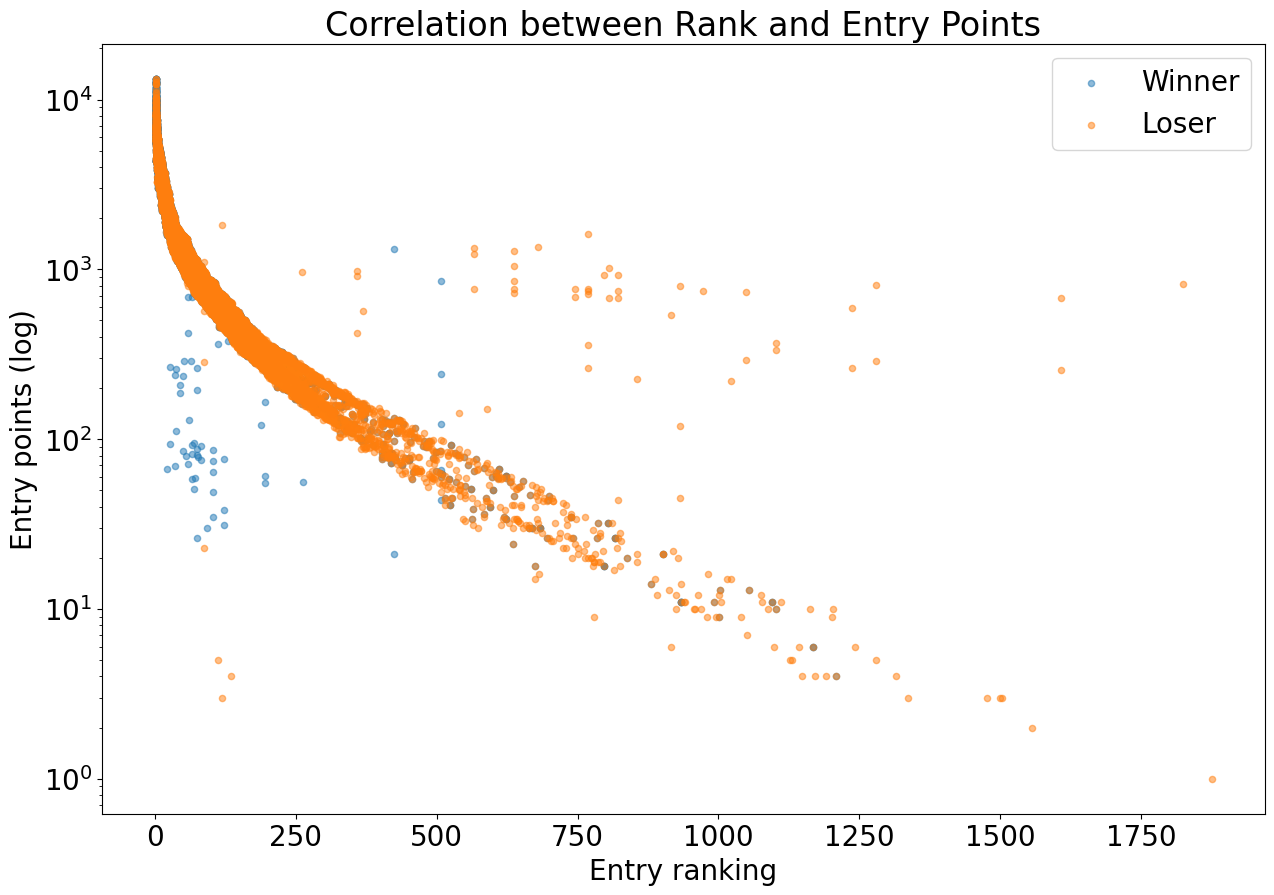

In [25]:
#scatter plot of correlation between Rank and Entry Points

plt.scatter(wta.WRank, wta.WPts, s=20, alpha=0.5, label = 'Winner')
plt.scatter(wta.LRank, wta.LPts, s=20, alpha=0.5, label = 'Loser')

plt.yscale('log')
plt.legend()
plt.xlabel('Entry ranking')
plt.ylabel('Entry points (log)')
plt.title('Correlation between Rank and Entry Points')

As expected, generally, highest ranking players have highest number of entry points, regardless of the match result. Also worth noting that there are a number of players who lost the match and have a lower rank despite having a considerably hign number of entry points.

Text(0, 0.5, 'Count')

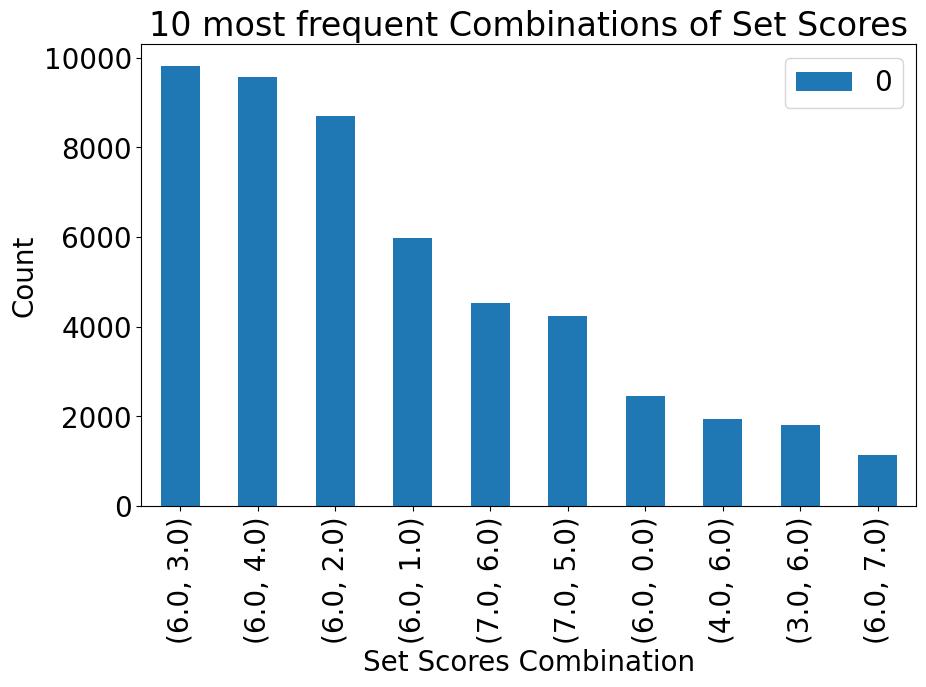

In [27]:
set1 = wta[['W1', 'L1']].groupby(['W1', 'L1']).size().reset_index()
set2 = wta[['W2', 'L2']].groupby(['W2', 'L2']).size().reset_index()
set2.columns = ['W1', 'L1', 0]
set3 = wta[['W3', 'L3']].groupby(['W3', 'L3']).size().reset_index()
set3.columns = ['W1', 'L1', 0]

sets_scores = pd.concat([set1, set2, set3]).groupby(['W1', 'L1']).sum().sort_values(by = 0, ascending = False)
sets_scores.iloc[1:11].plot(kind = 'bar', figsize = (10, 6))
plt.title('10 most frequent Combinations of Set Scores')
plt.xlabel('Set Scores Combination')
plt.ylabel('Count')

The most frequent combinations of set scores are those where the Winner get 6 points against 3 or 4, which seems pretty reasonable distribution of scores. We also got an impressive detail that there is a 6:0 combo in Top 10 combinations, which means that sets with an absolute win happen quite often. 

Text(0, 0.5, 'Count')

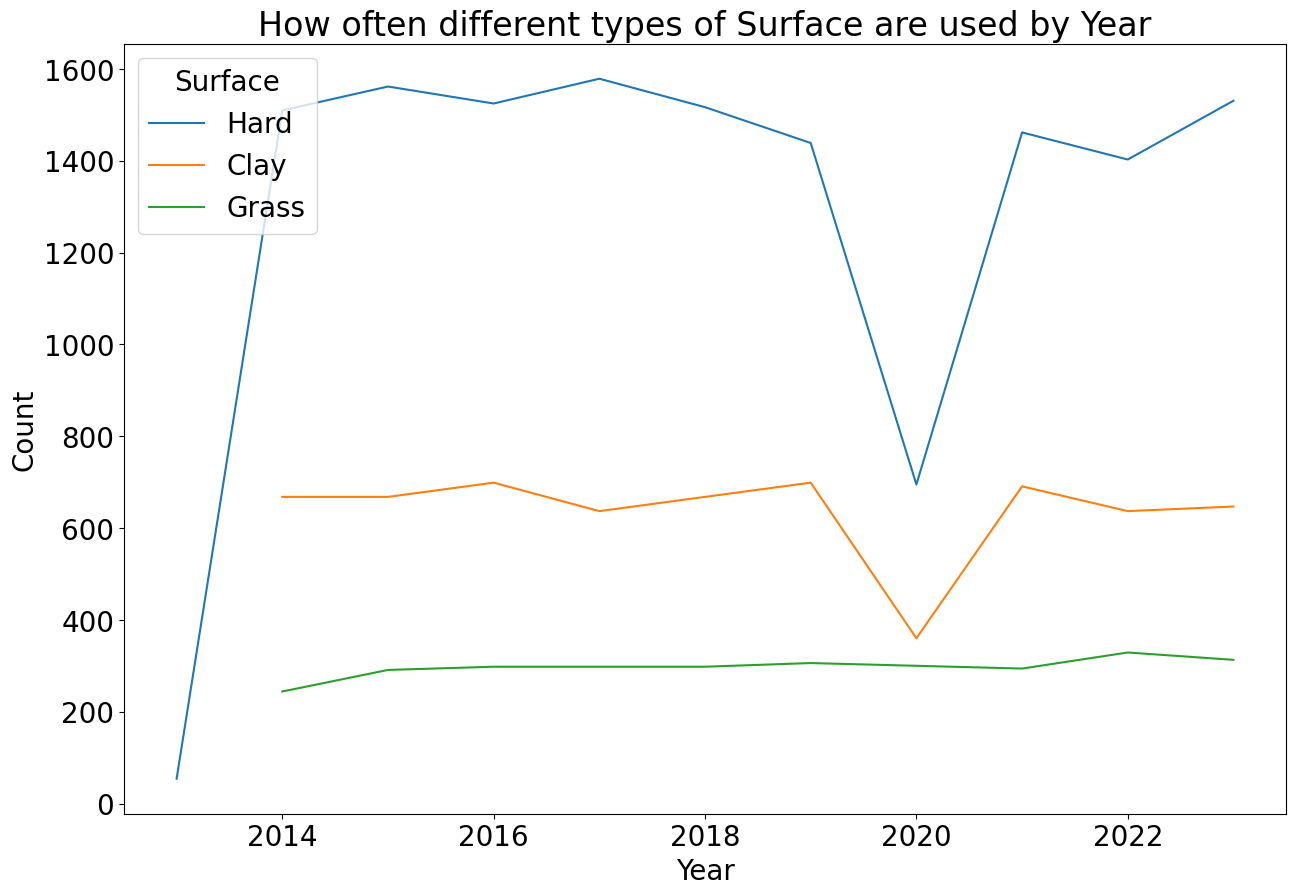

In [29]:
wta['Year'] = pd.to_datetime(wta['Date']).dt.year
surface_by_year = wta.groupby(['Year', 'Surface']).size().reset_index(name = 'Count')

sns.lineplot(data = surface_by_year, x = 'Year', y = 'Count', hue = 'Surface', palette = 'tab10')
plt.title('How often different types of Surface are used by Year')
plt.xlabel('Year')
plt.ylabel('Count')

Hard surface is the most popular type of surface used on tennis matches, probably explained by the fact that using an indoor spaces are more convinient due to weather dependency. Games on fresh air got their benefit once COVID-19 hit in 2020, which dramatically affected all other court surfaces usage except for the grass court. However, once lockdown got was over, indoor games went back to usual numbers.

Note, that set scores 0:0 weren't plotted since they don't represent the real set scores and only replace missing values for scores.

Text(0, 0.5, 'Frequency')

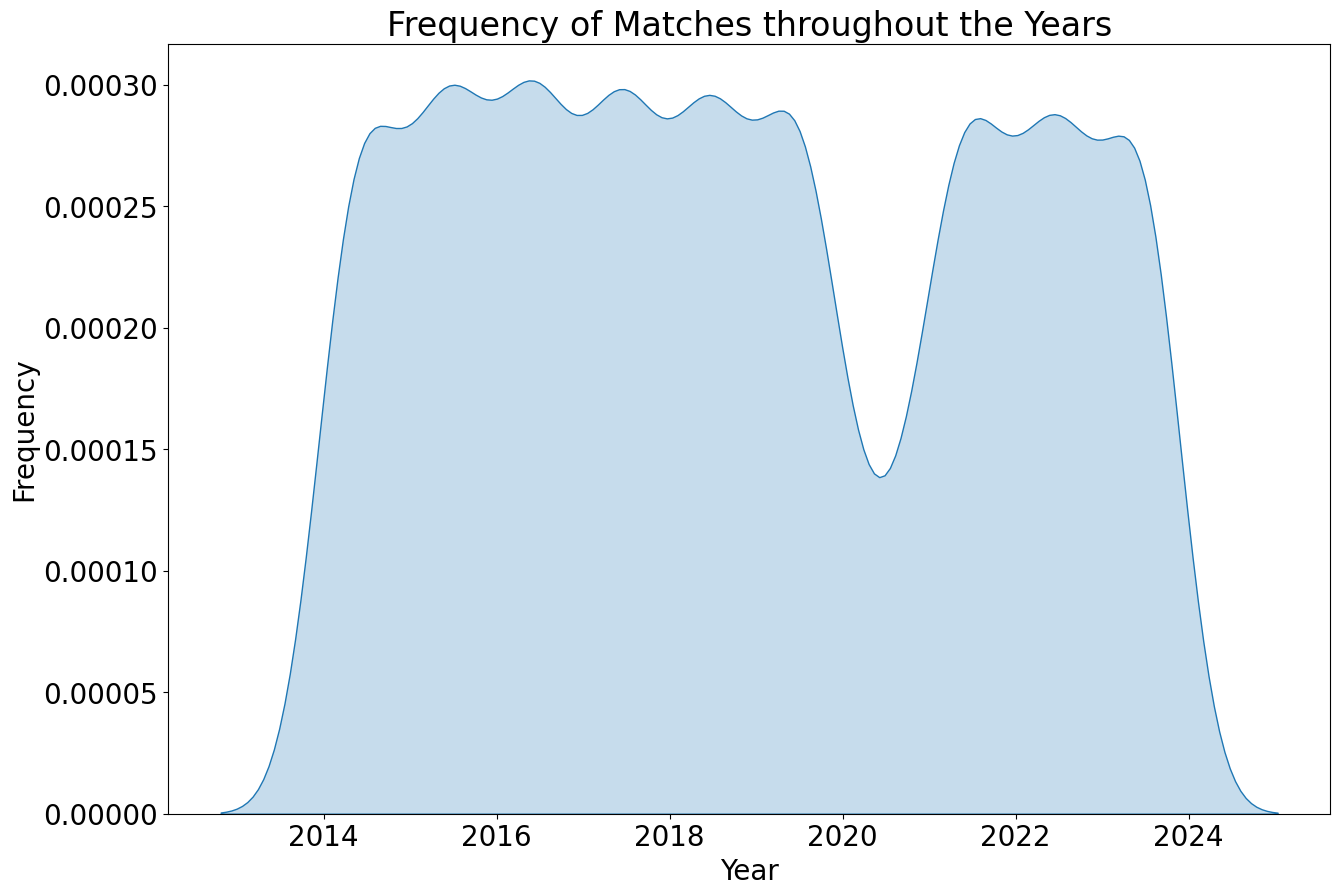

In [31]:
sns.kdeplot(data = wta, x = 'Date', fill = True)
plt.title('Frequency of Matches throughout the Years')
plt.xlabel('Year')
plt.ylabel('Frequency')

There is some seasonal trends that are probably explained by the certain times of the year when tennis tournaments are held. We can also notice a small decline of the frequency of mathes throughout the whole period of time. The most obvious drop in numbers of matches happenede in 2020-2021, which can be explained by COVID-19 lockdown period. 

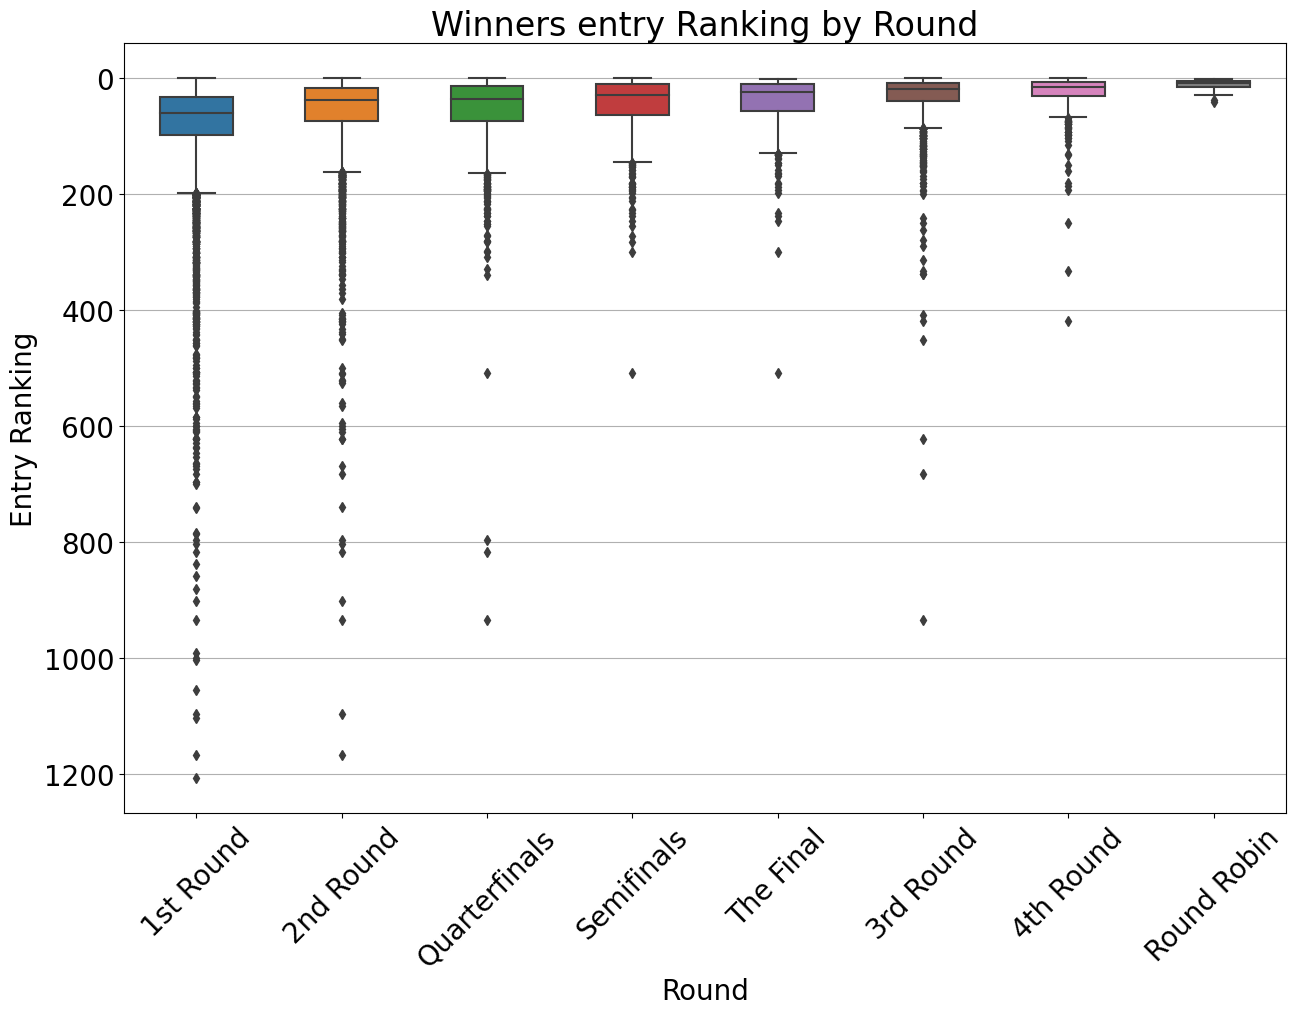

In [33]:
sns.boxplot(x = 'Round', y = 'WRank', data = wta, width=0.5).invert_yaxis()
plt.title('Winners entry Ranking by Round')
plt.xlabel('Round')
plt.ylabel('Entry Ranking')
plt.xticks(rotation = 45)
plt.grid(axis = 'y')

Boxplot shows the ranking of winners by each round. Although 3rd Round have some outliers, the graph clearly demonstrates that each next round have higher rank players left.

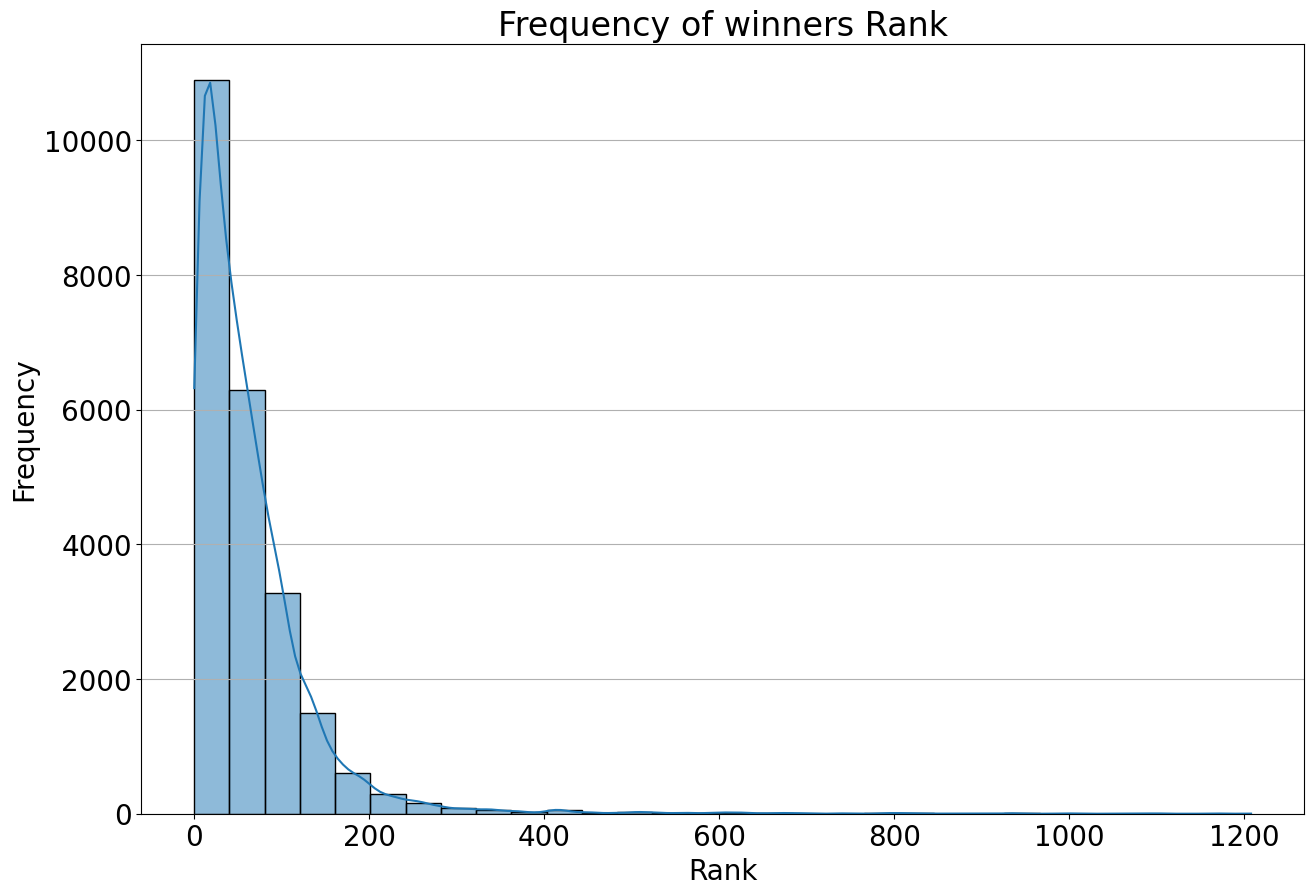

In [35]:
sns.histplot(wta['WRank'], bins = 30, kde = True)
plt.title('Frequency of winners Rank')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.grid(axis = 'y')

The histogram shows the distribution of winner's rank. We can see that the half of winners' rank lies in the range of 0-80, and almost fades away after around 300. 

# Analysis and plotting


### Top 10 players by total wins

In [39]:
top10 = wta['Winner'].value_counts().head(10)
top10

Winner
Pliskova Ka.    373
Halep S.        353
Svitolina E.    324
Kvitova P.      320
Garcia C.       306
Kerber A.       302
Muguruza G.     287
Wozniacki C.    251
Keys M.         250
Kasatkina D.    249
Name: count, dtype: int64

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Pliskova Ka.'),
  Text(1, 0, 'Halep S.'),
  Text(2, 0, 'Svitolina E.'),
  Text(3, 0, 'Kvitova P.'),
  Text(4, 0, 'Garcia C.'),
  Text(5, 0, 'Kerber A.'),
  Text(6, 0, 'Muguruza G.'),
  Text(7, 0, 'Wozniacki C.'),
  Text(8, 0, 'Keys M.'),
  Text(9, 0, 'Kasatkina D.')])

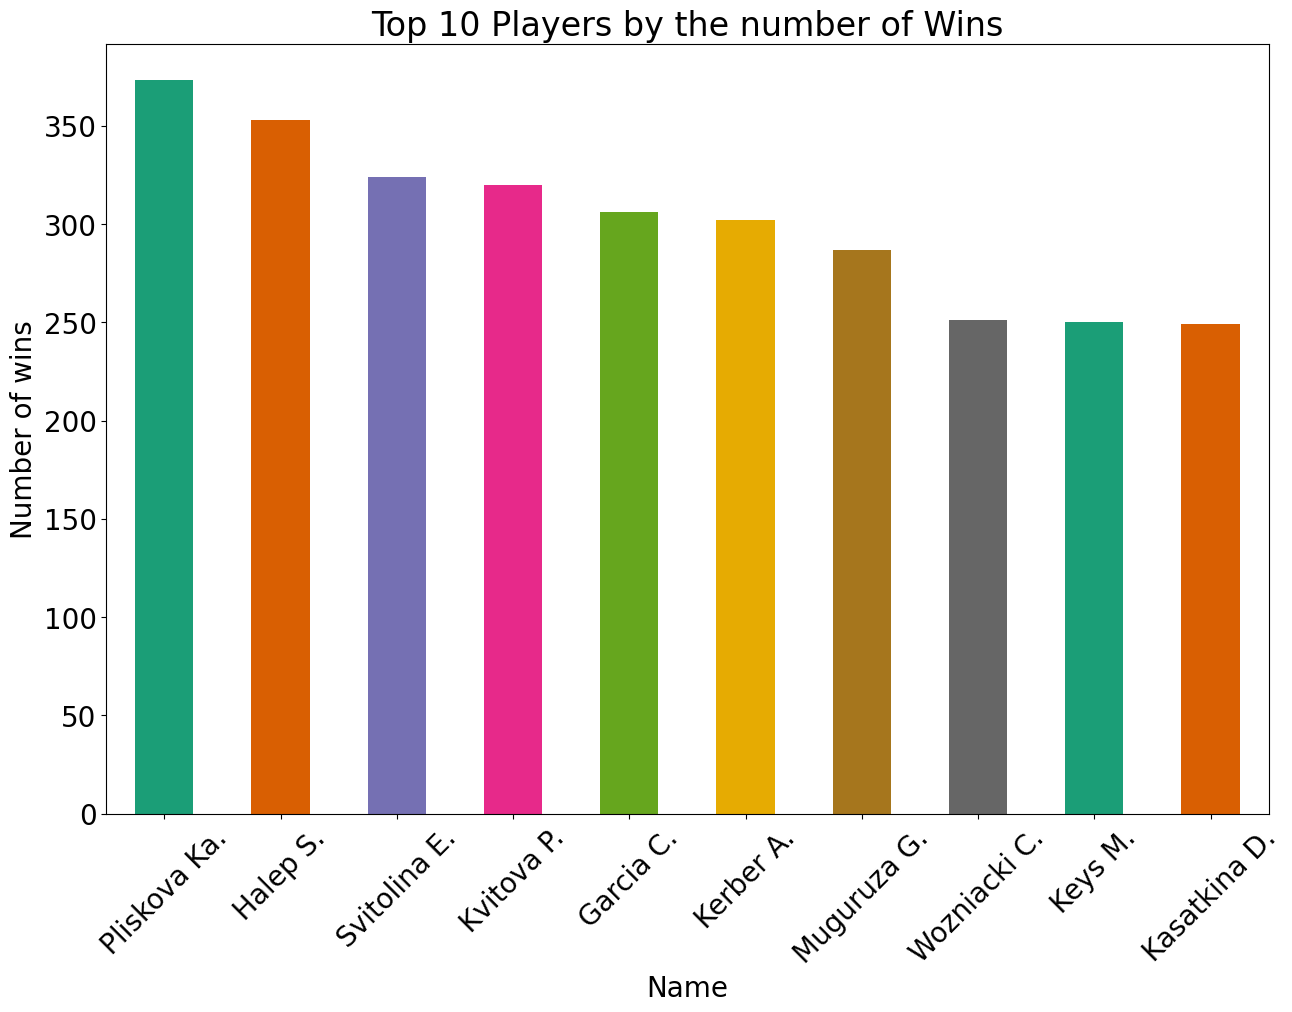

In [40]:
top10.plot(kind = 'bar', color = sns.color_palette("Dark2"))
plt.title('Top 10 Players by the number of Wins')
plt.xlabel('Name')
plt.ylabel('Number of wins')
plt.xticks(rotation = 45)


The number of winning games between top 10 players decreases considerably smoothly, which tells us that the competition is pretty tense and it's hard to point on an absolute champion. However, players on 8th to 10th have pretty tight number of wins, which might signify the potential change of their position in top 10 in foreseeable futre.

### Top 10 players by the largest number of First Round tournament losses across all 10 years

In [43]:
top10L = wta[wta['Round'] == '1st Round']['Loser'].value_counts().head(10)
#sort_values(by = 0, ascending = False).
top10L

Loser
Zhang S.          105
Siniakova K.       98
Mladenovic K.      89
Watson H.          85
Babos T.           84
Doi M.             82
Schmiedlova A.     79
Begu I.            78
Maria T.           78
Riske A.           78
Name: count, dtype: int64

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Zhang S.'),
  Text(1, 0, 'Siniakova K.'),
  Text(2, 0, 'Mladenovic K.'),
  Text(3, 0, 'Watson H.'),
  Text(4, 0, 'Babos T.'),
  Text(5, 0, 'Doi M.'),
  Text(6, 0, 'Schmiedlova A.'),
  Text(7, 0, 'Begu I.'),
  Text(8, 0, 'Maria T.'),
  Text(9, 0, 'Riske A.')])

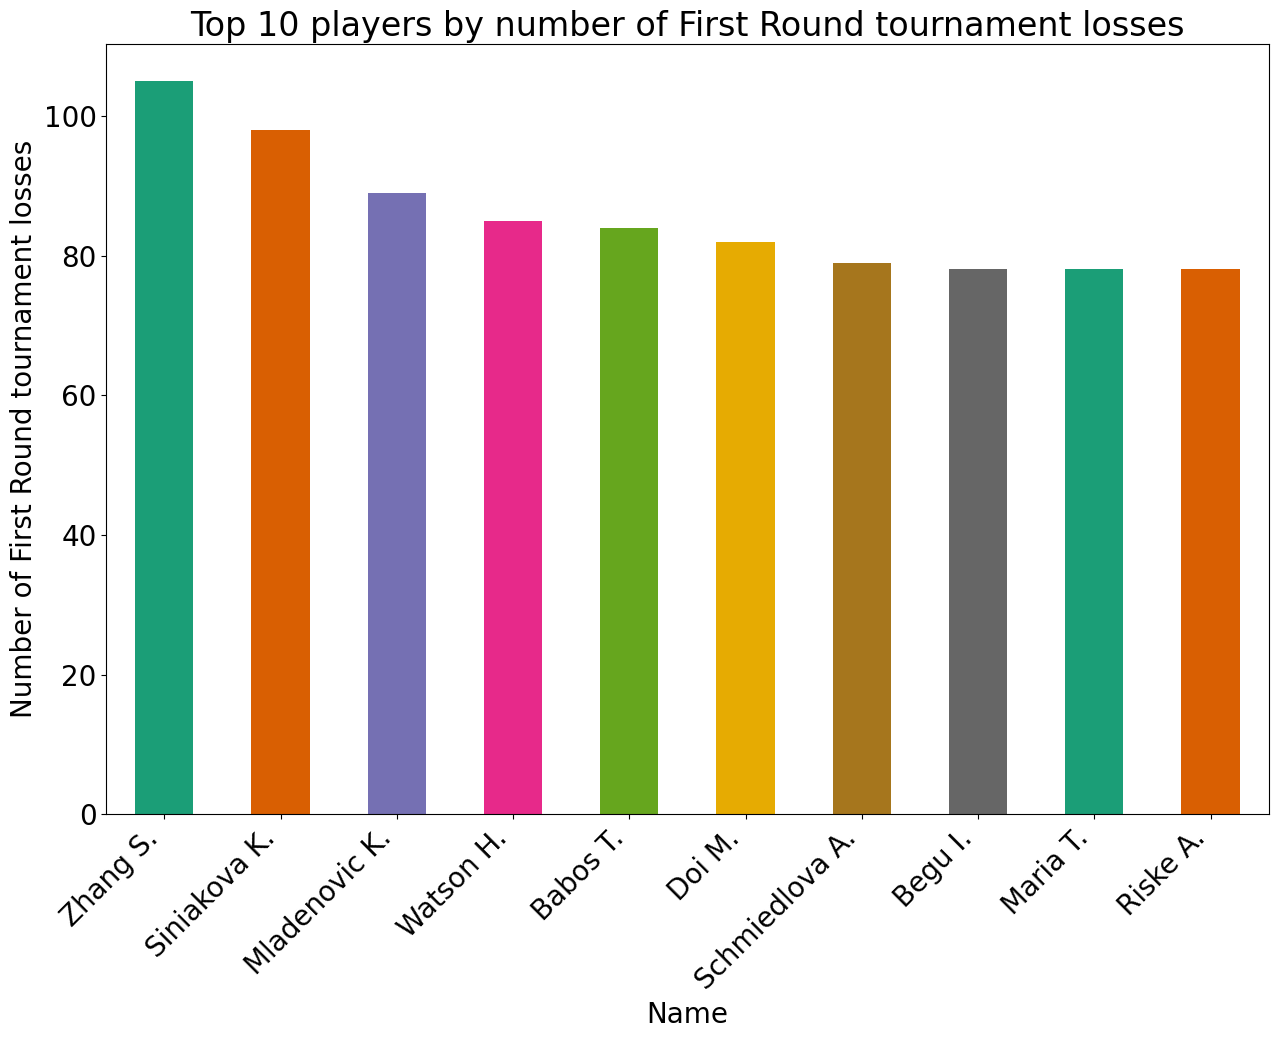

In [44]:
top10L.plot(kind = 'bar', color = sns.color_palette("Dark2"))
plt.title('Top 10 players by number of First Round tournament losses')
plt.xlabel('Name')
plt.ylabel('Number of First Round tournament losses')
plt.xticks(rotation = 45, ha = 'right')


According to the largest number of First Round tournament losses across all 10 years, player Zhang S. has the most losses (105 throughout 10 years of tournaments). The following players in the list have gradually decreasing number of losses, until it evens out for the last 4 players in the list, which might indicate that having around 78 lost games in the First Round is a comparatively average index.

### 5 biggest upsets for each year in the dataset based on ranking differentials

In [47]:
wta['Rank_diff'] = wta['WRank'] - wta['LRank']
wta['Set_score'] = wta['Wsets'].astype(int).astype(str) + '-' + wta['Lsets'].astype(int).astype(str)
wta_year = wta.groupby('Year')

top5_upsets = pd.DataFrame(columns=['Year', 'Winner', 'WRank', 'Loser', 'LRank', 'Set_score', 'Tournament', 'Rank_diff'])

for year, group in wta_year:
    sort_match = group.sort_values(by = 'Rank_diff', ascending = False).head(5)
    top5_upsets = pd.concat([top5_upsets, 
                            sort_match[['Year', 'Winner', 'WRank', 'Loser', 'LRank', 'Set_score', 'Tournament', 
                                        'Rank_diff']]], 
                            ignore_index=True)

top5_upsets

,Year,Winner,WRank,Loser,LRank,Set_score,Tournament,Rank_diff
0,2013,Konjuh A.,259.0,Vinci R.,14.0,2-1,ASB Classic,245.0
1,2013,Chan Y.J.,257.0,Zhang S.,52.0,2-1,Shenzhen Open,205.0
2,2013,Barty A.,190.0,Hantuchova D.,33.0,2-0,Brisbane International,157.0
3,2013,Fichman S.,116.0,Cirstea S.,22.0,2-0,ASB Classic,94.0
4,2013,Friedsam A.L.,122.0,Jovanovski B.,36.0,2-0,Shenzhen Open,86.0
...,...,...,...,...,...,...,...,...
50,2023,Brady J.,1055.0,Kalinina A.,28.0,2-0,Citi Open,1027.0
51,2023,Strycova B.,1103.0,Zanevska M.,77.0,2-1,Internazionali BNL d'Italia,1026.0
52,2023,Williams V.,1003.0,Volynets K.,113.0,2-0,ASB Classic,890.0
53,2023,Routliffe E.,858.0,Hsieh S.W.,23.0,2-1,Internationaux de Strasbourg,835.0


### Top 10 players at year-end in 2018 and how have their rankings changed over the period of 2014 to 2023

In [49]:
wta2018 = wta[wta['Year'] == 2018]
top10_2018 = wta2018.groupby('Winner')['WRank'].mean().sort_values().head(10)
top10_2018_full = wta[wta['Winner'].isin(top10_2018.index)]
top10_2018_full

,WTA,Location,Tournament,Date,Tier,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,WPts,LPts,W1,L1,W2,L2,W3,...,Wsets,Lsets,Comment,B365W,B365L,EXW,EXL,LBW,LBL,PSW,PSL,SJW,SJL,MaxW,MaxL,AvgW,AvgL,Year,Rank_diff,Set_score
1,2,Brisbane,Brisbane International,2013-12-29,Premier,Outdoor,Hard,1st Round,3,Svitolina E.,Lepchenko V.,45.0,54.0,1160.0,1087.0,6.0,3.0,6.0,3.0,0.0,...,2.0,0.0,Completed,1.83,1.83,2.00,1.80,2.10,1.67,2.06,1.84,2.10,1.67,2.10,1.89,2.00,1.77,2013,-9.0,2-0
25,1,Auckland,ASB Classic,2013-12-30,International,Outdoor,Hard,1st Round,3,Muguruza G.,Mchale C.,63.0,66.0,933.0,882.0,6.0,4.0,6.0,3.0,0.0,...,2.0,0.0,Completed,2.20,1.61,2.45,1.52,2.10,1.67,2.43,1.62,2.25,1.57,2.58,1.67,2.34,1.57,2013,-3.0,2-0
28,1,Auckland,ASB Classic,2013-12-30,International,Outdoor,Hard,1st Round,3,Williams V.,Hlavackova A.,47.0,134.0,1147.0,470.0,6.0,3.0,7.0,6.0,0.0,...,2.0,0.0,Completed,1.16,4.50,1.22,4.00,1.25,3.75,1.20,5.07,1.22,3.75,1.25,5.10,1.20,4.41,2013,-87.0,2-0
32,1,Auckland,ASB Classic,2013-12-30,International,Outdoor,Hard,1st Round,3,Pliskova Ka.,Ormaechea P.,71.0,62.0,839.0,954.0,7.0,6.0,6.0,1.0,0.0,...,2.0,0.0,Completed,1.57,2.25,1.62,2.25,1.57,2.25,1.61,2.46,1.62,2.20,1.67,2.46,1.60,2.30,2013,9.0,2-0
62,1,Auckland,ASB Classic,2014-01-01,International,Outdoor,Hard,2nd Round,3,Muguruza G.,Fichman S.,63.0,116.0,933.0,576.0,1.0,6.0,6.0,3.0,6.0,...,2.0,1.0,Completed,1.57,2.25,1.62,2.25,1.53,2.38,1.61,2.49,1.57,2.38,1.70,2.55,1.59,2.31,2014,-53.0,2-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23090,49,Beijing,China Open,2023-10-03,Premier,Outdoor,Hard,2nd Round,3,Garcia C.,Putintseva Y.,10.0,75.0,3335.0,877.0,6.0,3.0,3.0,6.0,6.0,...,2.0,1.0,Completed,1.62,2.30,0.00,0.00,0.00,0.00,1.61,2.45,0.00,0.00,1.64,2.46,1.58,2.37,2023,-65.0,2-1
23095,49,Beijing,China Open,2023-10-04,Premier,Outdoor,Hard,3rd Round,3,Ostapenko J.,Pegula J.,17.0,4.0,2505.0,5955.0,6.0,4.0,6.0,2.0,0.0,...,2.0,0.0,Completed,2.50,1.53,0.00,0.00,0.00,0.00,2.69,1.53,0.00,0.00,2.75,1.59,2.60,1.49,2023,13.0,2-0
23102,49,Beijing,China Open,2023-10-05,Premier,Outdoor,Hard,3rd Round,3,Garcia C.,Kalinina A.,10.0,28.0,3335.0,1572.0,6.0,3.0,6.0,2.0,0.0,...,2.0,0.0,Completed,1.73,2.10,0.00,0.00,0.00,0.00,1.67,2.35,0.00,0.00,1.74,2.44,1.66,2.21,2023,-18.0,2-0
23295,56,Zhuhai,WTA Elite Trophy,2023-10-25,Tour Championships,Indoor,Hard,Round Robin,3,Garcia C.,Keys M.,20.0,11.0,2035.0,2737.0,6.0,3.0,7.0,6.0,0.0,...,2.0,0.0,Completed,2.00,1.80,0.00,0.00,0.00,0.00,1.97,1.89,0.00,0.00,2.00,1.99,1.92,1.87,2023,9.0,2-0


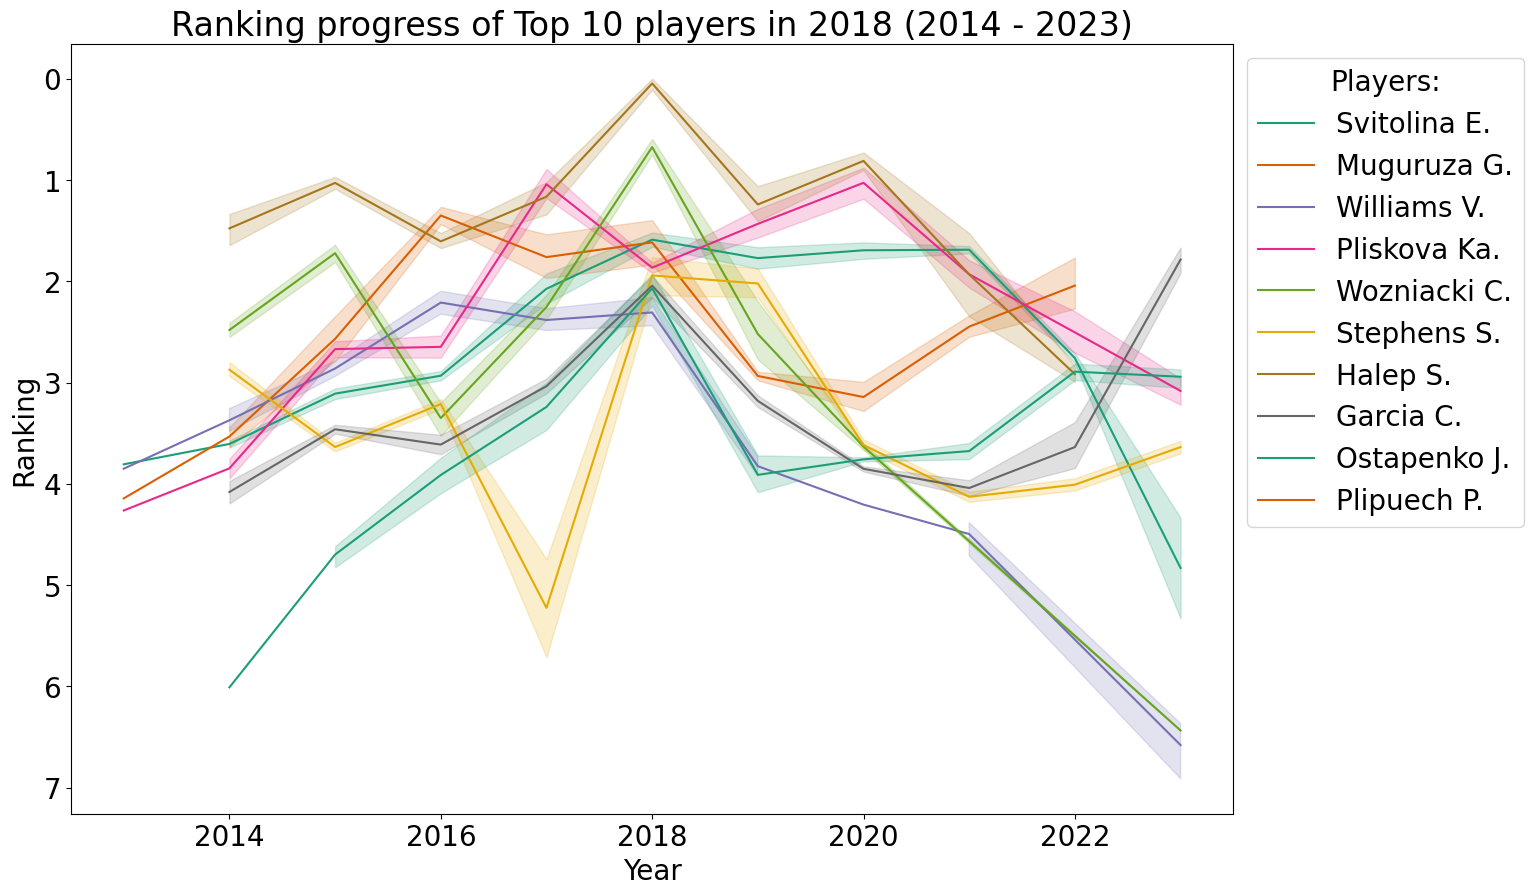

In [50]:
plot_data = top10_2018_full[top10_2018_full['WRank'] > 0].copy()

sns.lineplot(
    x = 'Year', 
    y = np.log(plot_data['WRank']), 
    hue = 'Winner', 
    data = plot_data, 
    palette = 'Dark2'
).invert_yaxis()

plt.title('Ranking progress of Top 10 players in 2018 (2014 - 2023)')
plt.xlabel('Year')
plt.ylabel('Ranking')
plt.legend(title = 'Players:',  bbox_to_anchor=(1, 1))


Line graph demonstrates that all the players had the closest points to the highest rank in 2018 - year, according to which we assembled the list. It is reasonable to say that the overall pattern of rank prgress is comapratively similar among those 10 players: in the beginning of 2014 their rank was a bit lower, was going up by 2018 and going down again in the rest of the time period. However, some players had significant rank drops that probably was determined by inactiveyears: Stephens S. in 2017, Williams V.	and Wozniacki C. after 2021, Svitolina E. after 2022.

Note: Ranking was log transformed, so that significantly low ranks of some players wouldn't deform the rest of the graph and the lines could be clearly interpreted. The y-axs was also inverted for better readability of ranks, being 0 as the highest rank.

In [52]:
#from bokeh.plotting import figure, output_notebook, show
#output_notebook()
#p2 = figure(title = '')
#p2.scatter(top10_2018_full['Year'], np.log(wta['WRank']))
           #, color = 'Dark2') 
        #line = 'Winner'
#show(p2)

# Advanced analysis


### Tournaments have had on average the most upsets

In [55]:
wta['Upset'] = wta['WRank'] > wta['LRank']

top10_tours = wta.groupby('Tournament')['Upset'].mean().sort_values(ascending = False).head(10)
top10_tours

Tournament
Sony Ericsson Championships    0.533333
Ladies Open Biel Bienne        0.516129
MUSC Health Women's Open       0.516129
Moscow River Cup               0.516129
BNP Paribas WTA Finals         0.511111
Copa Colsanitas                0.494624
Baltic Open                    0.483871
Tashkent Open                  0.483871
Budapest Open                  0.483871
Viking International           0.483871
Name: Upset, dtype: float64

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]),
 [Text(0.0, 0, '0.0'),
  Text(0.1, 0, '0.1'),
  Text(0.2, 0, '0.2'),
  Text(0.30000000000000004, 0, '0.3'),
  Text(0.4, 0, '0.4'),
  Text(0.5, 0, '0.5'),
  Text(0.6000000000000001, 0, '0.6')])

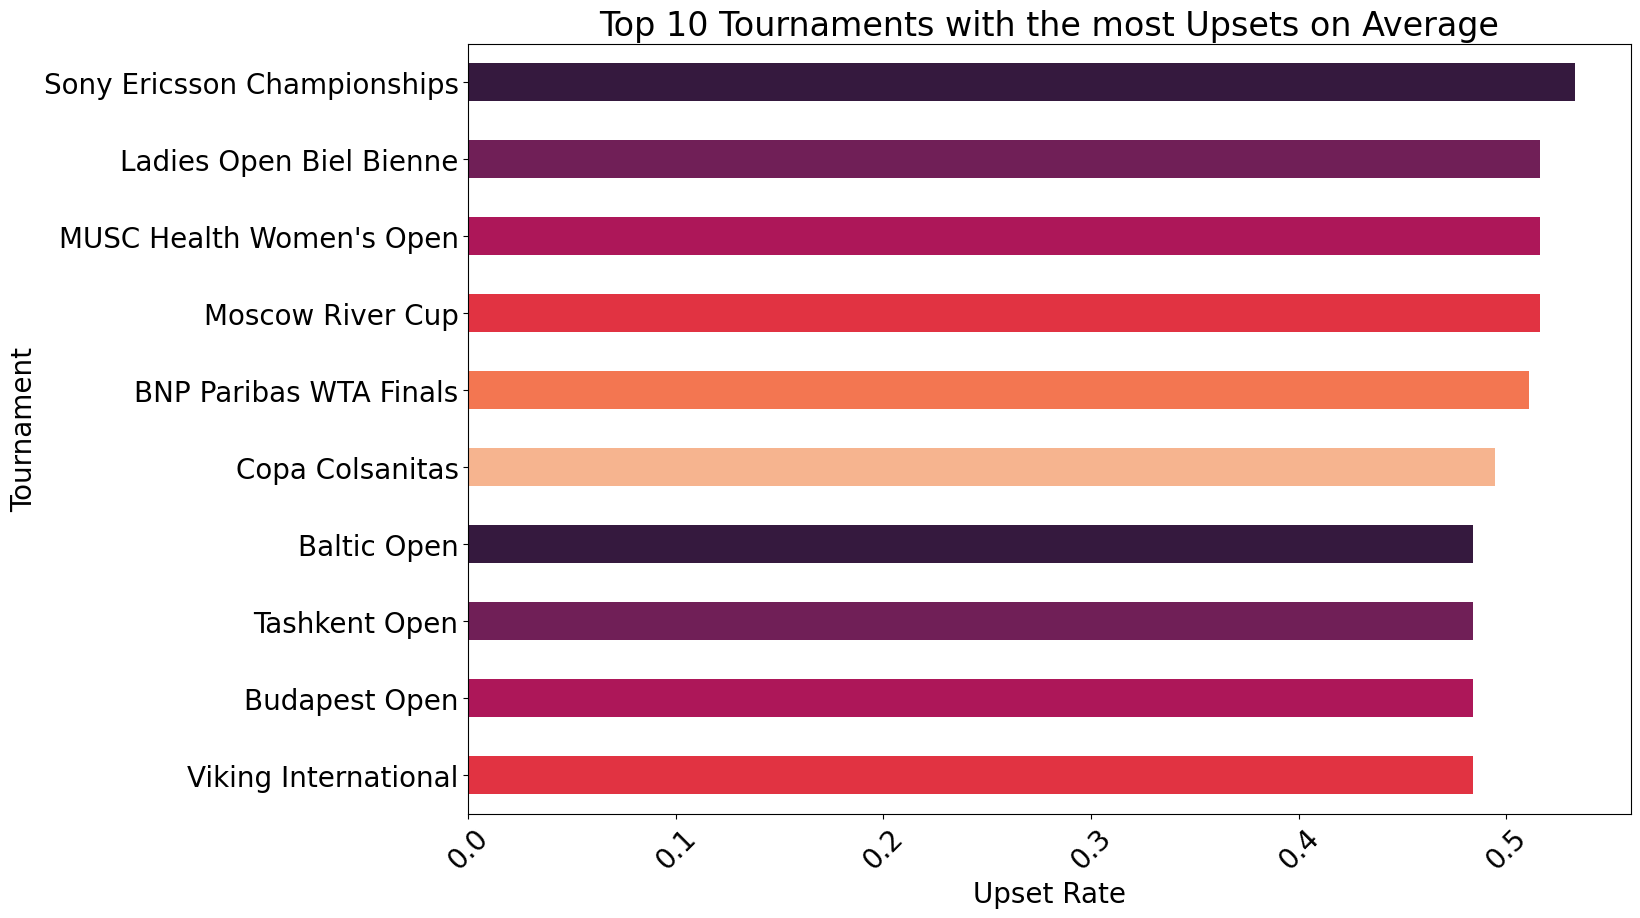

In [56]:
top10_tours.plot(kind = 'barh', color = sns.color_palette("rocket")).invert_yaxis()
plt.title('Top 10 Tournaments with the most Upsets on Average')
plt.ylabel('Tournament')
plt.xlabel('Upset Rate')
plt.xticks(rotation = 45)


### Top 10 ranked players (by ranking) at the end of 2023.

In [58]:
top10_2023 = wta[wta['Year'] == 2023].groupby('Winner')['WRank'].last().nsmallest(10)
top10_2023_match = wta[(wta['Year'] == 2023) 
                       & (wta['Winner'].isin(top10_2023.index)
                          & (wta['Loser'].isin(top10_2023.index)))]
win_loss = pd.DataFrame(index = top10_2023.index, columns = top10_2023.index, data = 0)

for index, match in top10_2023_match.iterrows():
    winner = match['Winner']
    loser = match['Loser']
    win_loss.at[winner, loser] += 1
    win_loss.at[loser, winner] -= 1

win_loss

Winner,Sabalenka A.,Swiatek I.,Gauff C.,Rybakina E.,Pegula J.,Sakkari M.,Jabeur O.,Vondrousova M.,Krejcikova B.,Muchova K.
Winner,,,,,,,,,,
Sabalenka A.,0,-1,0,0,-1,3,0,1,2,-2
Swiatek I.,1,0,3,-3,1,0,2,2,-1,2
Gauff C.,0,-3,0,1,-1,2,1,2,0,2
Rybakina E.,0,3,-1,0,0,1,-1,1,0,1
Pegula J.,1,-1,1,0,0,2,0,-1,0,1
Sakkari M.,-3,0,-2,-1,-2,0,0,0,0,-2
Jabeur O.,0,-2,-1,1,0,0,0,-2,0,0
Vondrousova M.,-1,-2,-2,-1,1,0,2,0,0,-1
Krejcikova B.,-2,1,0,0,0,0,0,0,0,0


Some players have more positive results than others, which indicates that they have more wins than loses with top 10 players of the year. Others show the opposite: e.g. player Sakkari M. has either negative results or 0, which says that she couldn't overplay any of the top 10 players that year.

Also there is a lot of zero or close to zero results, which can be interpreted as nearly the same level of excellence between the best 10 players of 2023. 

### Top 5 players with the longest winning streaks between 2014 – 2023

In [61]:
streaks = {}

for player in wta['Winner'].unique():
    matches = wta[wta['Winner'] == player]
    matches = matches.sort_values(by = 'Date')
    
    streakstart = 0
    streakfull = 0
    start = None
    end = None
    
    for index, match in matches.iterrows():
        year = match['Year']
        if end is None or year == end + 1:
            streakstart += 1
        else:
            streakstart = 1  
            start = year
        
        if streakstart > streakfull:
            streakfull = streakstart
            end = year  
        
        end = year
    
    streaks[player] = (streakfull, start, end)

players = sorted(streaks.items(), key = lambda x: x[1][0], reverse = True)[:5]

for player, (streak, start, end) in players:
    print(f"Player: {player}, Streak: {streak}, Started: {start}, Ended: {end}")


Player: Stosur S., Streak: 4, Started: 2019, Ended: 2022
Player: Tomova V., Streak: 4, Started: 2023, Ended: 2023
Player: Peng S., Streak: 3, Started: 2020, Ended: 2020
Player: King V., Streak: 3, Started: 2016, Ended: 2018
Player: Williams V., Streak: 3, Started: 2023, Ended: 2023


### Top 10 players by the percentage of tiebreaks won

In [63]:
wta['S1'] = wta['W1'].astype(int).astype(str) + '-' + wta['L1'].astype(int).astype(str)
wta['S2'] = wta['W2'].astype(int).astype(str) + '-' + wta['L2'].astype(int).astype(str)
wta['S3'] = wta['W3'].astype(int).astype(str) + '-' + wta['L3'].astype(int).astype(str)

tb_match1 = wta[wta['S1'].str.contains('6-7', '7-6')]
tb_match2 = wta[wta['S2'].str.contains('6-7', '7-6')]
tb_match3 = wta[wta['S3'].str.contains('6-7', '7-6')]

tb_match = pd.concat([tb_match1, tb_match2, tb_match3])
tb_match

,WTA,Location,Tournament,Date,Tier,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,WPts,LPts,W1,L1,W2,L2,W3,...,B365L,EXW,EXL,LBW,LBL,PSW,PSL,SJW,SJL,MaxW,MaxL,AvgW,AvgL,Year,Rank_diff,Set_score,Upset,S1,S2,S3
78,2,Brisbane,Brisbane International,2014-01-02,Premier,Outdoor,Hard,Quarterfinals,3,Jankovic J.,Kerber A.,8.0,9.0,4170.0,3965.0,6.0,7.0,6.0,3.0,6.0,...,1.61,2.20,1.65,2.10,1.67,2.56,1.59,2.20,1.67,2.66,1.70,2.26,1.61,2014,-1.0,2-1,False,6-7,6-3,6-1
95,5,Sydney,Apai International,2014-01-06,Premier,Outdoor,Hard,1st Round,3,Mchale C.,Cornet A.,65.0,26.0,882.0,1840.0,6.0,7.0,6.0,2.0,7.0,...,1.72,2.00,1.80,2.20,1.62,2.16,1.76,2.00,1.80,2.20,1.87,2.02,1.76,2014,39.0,2-1,True,6-7,6-2,7-5
106,4,Hobart,Hobart International,2014-01-06,International,Outdoor,Hard,1st Round,3,Stosur S.,Brengle M.,17.0,147.0,2675.0,424.0,6.0,7.0,6.0,1.0,7.0,...,6.00,1.15,5.25,1.12,5.50,1.15,6.40,1.13,6.00,1.15,7.00,1.13,5.74,2014,-130.0,2-1,False,6-7,6-1,7-6
111,4,Hobart,Hobart International,2014-01-06,International,Outdoor,Hard,1st Round,3,Mladenovic K.,Soler Espinosa S.,54.0,79.0,1075.0,787.0,6.0,7.0,6.0,4.0,6.0,...,2.20,1.65,2.20,1.67,2.10,1.77,2.16,1.73,2.10,1.77,2.25,1.68,2.14,2014,-25.0,2-1,False,6-7,6-4,6-4
193,6,Melbourne,Australian Open,2014-01-14,Grand Slam,Outdoor,Hard,1st Round,3,Jovanovski B.,Cepelova J.,34.0,69.0,1475.0,849.0,6.0,7.0,6.0,1.0,6.0,...,2.62,1.50,2.50,1.53,2.38,1.45,2.97,1.53,2.50,1.56,2.97,1.49,2.58,2014,-35.0,2-1,False,6-7,6-1,6-3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23172,50,Hong Kong,Hong Kong Tennis Open,2023-10-12,WTA250,Outdoor,Hard,2nd Round,3,Trevisan M.,Frech M.,42.0,70.0,1227.0,924.0,6.0,3.0,6.0,7.0,6.0,...,1.91,0.00,0.00,0.00,0.00,1.95,1.93,0.00,0.00,2.00,1.95,1.90,1.88,2023,-28.0,2-1,False,6-3,6-7,6-3
23205,54,Monastir,Jasmin Open,2023-10-16,WTA250,Outdoor,Hard,1st Round,3,Errani S.,Zidansek T.,108.0,96.0,652.0,725.0,6.0,2.0,6.0,7.0,6.0,...,1.44,0.00,0.00,0.00,0.00,2.95,1.44,0.00,0.00,3.00,1.44,2.83,1.41,2023,12.0,2-1,True,6-2,6-7,6-3
23210,53,Cluj-Napoca,Transylvania Open,2023-10-16,WTA250,Indoor,Hard,1st Round,3,Tig P.M.,Matoula M.,462.0,327.0,116.0,190.0,6.0,4.0,6.0,7.0,6.0,...,2.63,0.00,0.00,0.00,0.00,1.49,2.76,0.00,0.00,1.50,3.00,1.47,2.65,2023,135.0,2-1,True,6-4,6-7,6-3
23297,56,Zhuhai,WTA Elite Trophy,2023-10-25,Tour Championships,Indoor,Hard,Round Robin,3,Zheng Q.,Vekic D.,18.0,24.0,2275.0,1815.0,6.0,4.0,6.0,7.0,6.0,...,3.75,0.00,0.00,0.00,0.00,1.33,3.58,0.00,0.00,1.36,3.75,1.29,3.53,2023,-6.0,2-1,False,6-4,6-7,6-4


In [64]:
tb_all = tb_match['Winner'].value_counts() + tb_match['Loser'].value_counts()
tb_win = tb_match['Winner'].value_counts()
tb_perc = (tb_win / tb_all) * 100
top10_tb = tb_perc.nlargest(10)
top10_tb

Peterson R.        88.888889
Arruabarrena L.    87.500000
Diyas Z.           87.500000
Osaka N.           83.333333
Pliskova Ka.       81.081081
Bacsinszky T.      80.000000
Garcia C.          80.000000
Jovanovski B.      80.000000
Krunic A.          80.000000
Wickmayer Y.       80.000000
Name: count, dtype: float64

### The most common set score combinations in matches with upsets

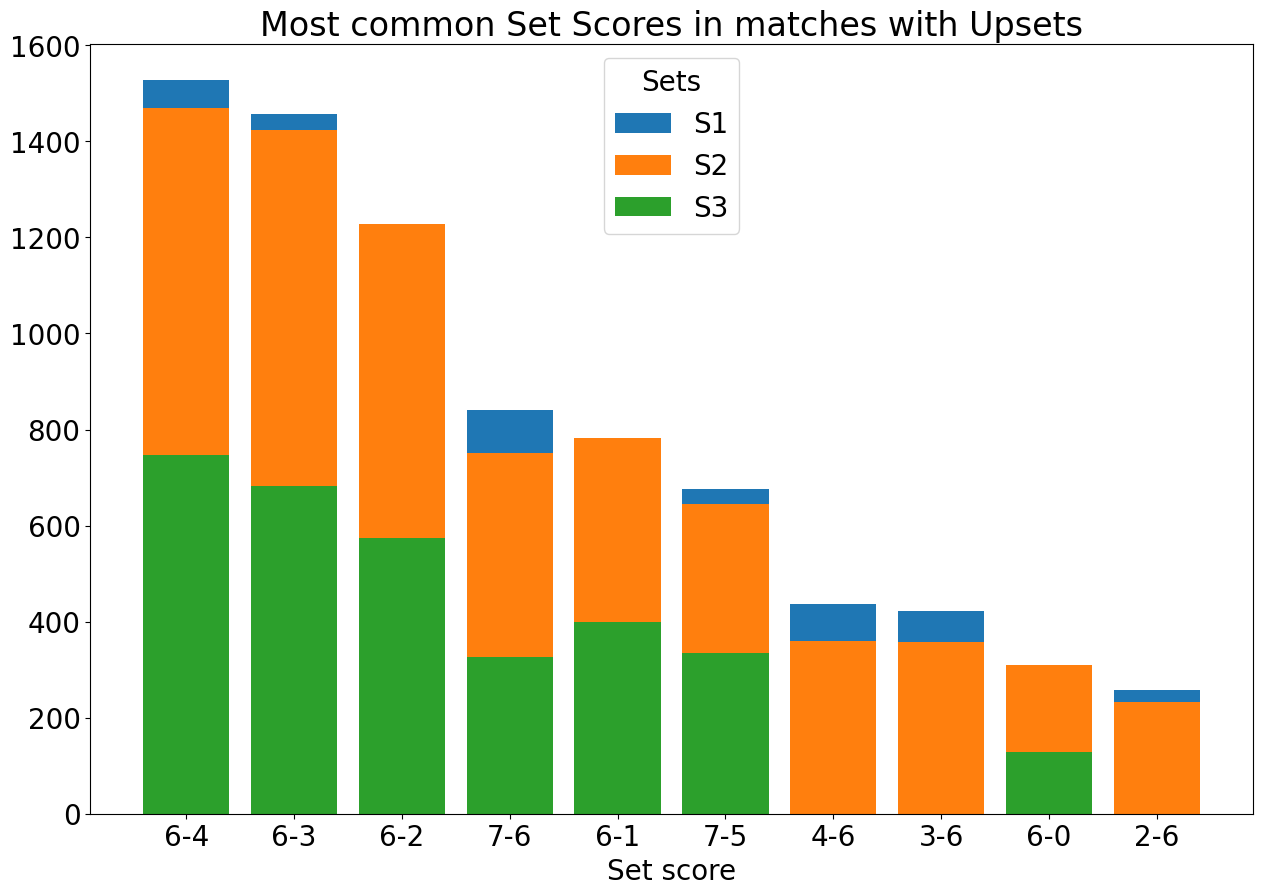

In [66]:
upsets = wta[wta['Upset']]
ss_count = pd.DataFrame()

for ss_col in ['S1', 'S2', 'S3']:
    ss_count[ss_col] = upsets[ss_col].value_counts()

ss_count['Total'] = ss_count.sum(axis = 1)
ss_count = ss_count.sort_values(by = 'Total', ascending = False).head(11)
ss_count = ss_count.drop('0-0', errors = 'ignore')

for ss_col in ss_count.columns[:-1]:
    plt.bar(ss_count.index, ss_count[ss_col], label = ss_col)

plt.xlabel('Set score')
plt.title('Most common Set Scores in matches with Upsets')
plt.legend(title='Sets')

Despite expecting that upset matches won't show much dramatic set results, we got 3 out 10 the most popular set scores combinations, where the player with lower rank won set with big difference (6-2, 6-1, 6-0). Other set score combinations seem pretty common not only for upset matches (6-4, 6-3, 7-6, 7-5). And we also have set outcomeswhere the winner of the match lost (4-6, 3-6, 2-6), which  didn't stop them to turn the tables.

### Locations that have the most tournaments a year

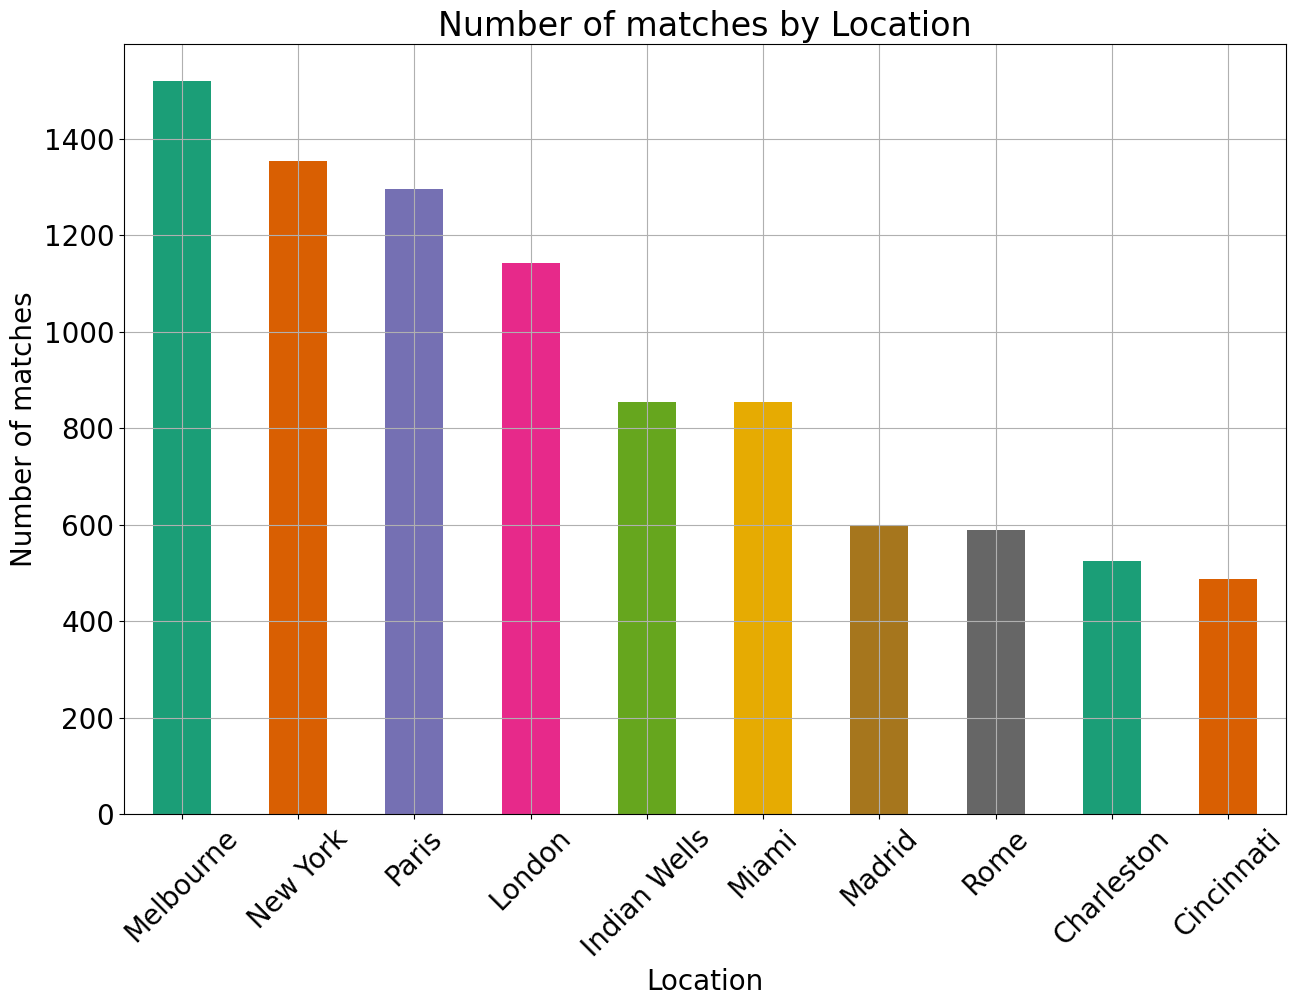

In [69]:
loc_count = wta['Location'].value_counts()
big_locs = loc_count[loc_count >= 50]
big_match = wta[wta['Location'].isin(big_locs.index)]
big_match_piv = big_match.pivot_table(index = 'Location', columns = wta['Year'], aggfunc = 'size')

big_match_piv.sum(axis = 1).sort_values(ascending = False).head(10).plot(kind = 'bar', color = sns.color_palette("Dark2"))
plt.title('Number of matches by Location')
plt.xlabel('Location')
plt.ylabel('Number of matches')
plt.xticks(rotation = 45)
plt.grid(True)

Melbourne, New York, Paris, London are the most popular location for tennis mathes having over 1000 mathes a year. Other popular locations are: Indian Wells, Miami, Rome, Charleston and Cincinnati.

### Top-10 players' performance on different types of surfaces

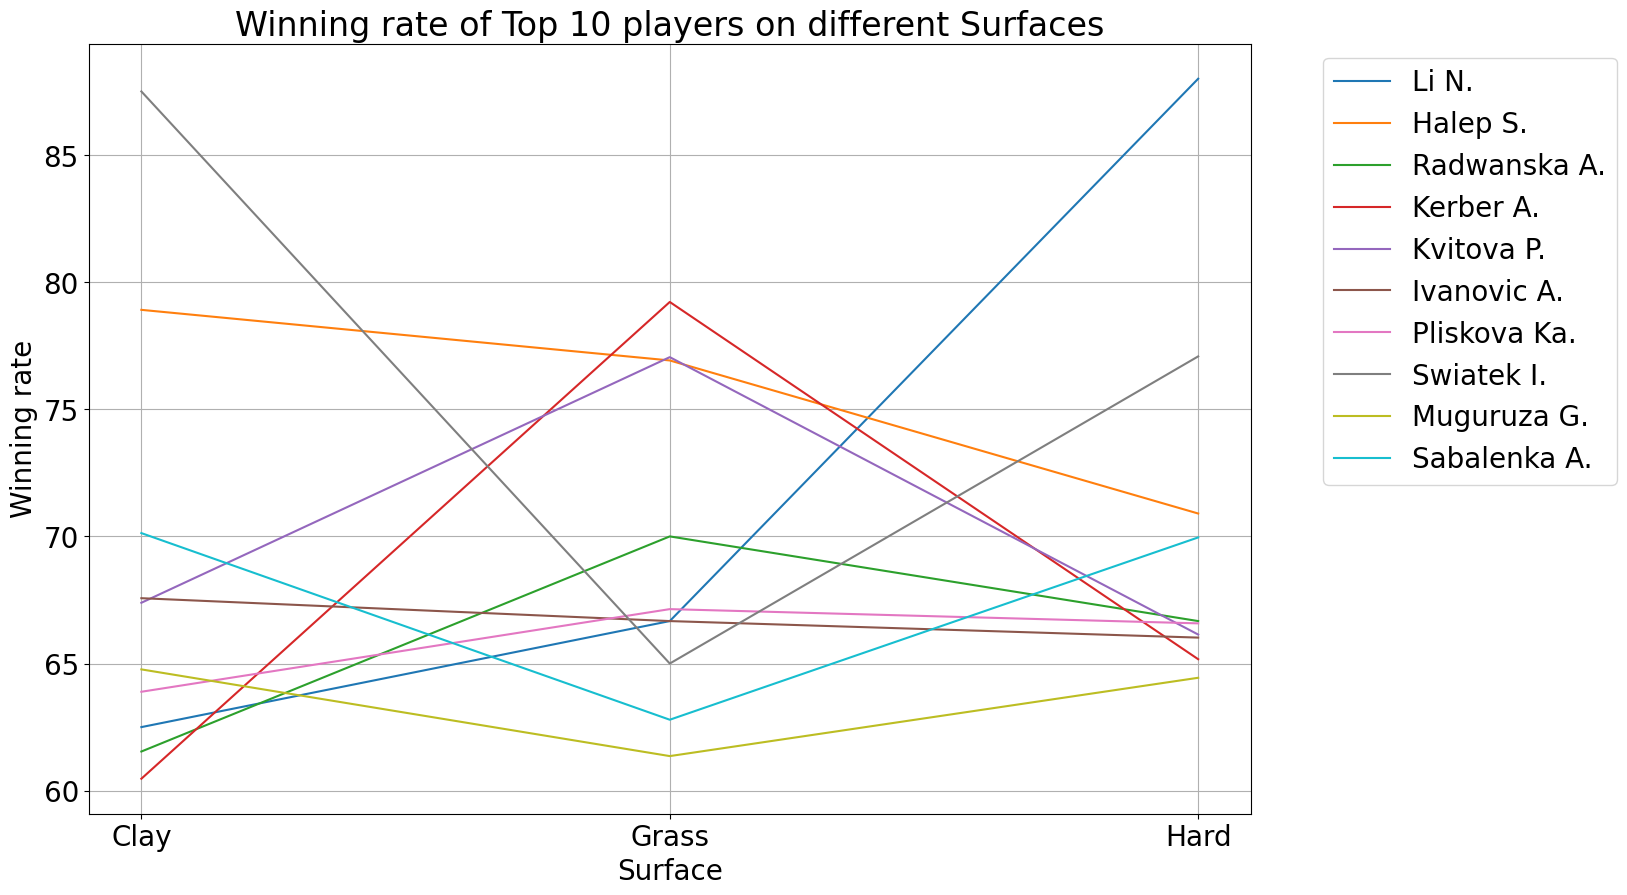

In [72]:
top10_rank = wta.groupby('Winner')['WRank'].mean().nsmallest(10).index
top10_wins = wta[wta['Winner'].isin(top10_rank)]
top10_losses = wta[wta['Loser'].isin(top10_rank)]

wins_surf = top10_wins.groupby(['Winner', 'Surface']).size().unstack()
loss_surf = top10_losses.groupby(['Loser', 'Surface']).size().unstack()
total_surf = wins_surf + loss_surf

winrate_surf = (wins_surf / total_surf * 100).round(2)

for player in top10_rank:
    player_winrate_surf = winrate_surf.loc[player]
    plt.plot(player_winrate_surf.index, player_winrate_surf.values, label = player)

plt.title('Winning rate of Top 10 players on different Surfaces')
plt.xlabel('Surface')
plt.ylabel('Winning rate')
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.grid(True)

I got an assumption that players might have "bias" towards certain type of court surface. On the grapph we can see that there's comparatively even distribution of players who:
    1) perform almost the same on all surfaces (Pliskova Ka., Ivanovic A., Halep S.);
    2) perform better on clay and hard surfaces (Muguruza G., Sabalenka A., Swiatek I.);
    3) perform better on grass (Radwanska A., Kvitova P., Kerber A.)
       And perfomance of Li N. drastically improves on hard surfaces, but considerably the same on clay and grass.
Not only this assumption can be considered as proven right, but also a certain correlation between surface types might be discovered. It is more common for players who perform better on clay/hard surfaces lose their dominance on grass surface, and vice versa.